Load and Inspect Data

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])
    ))

df = pd.read_csv(fn)


Saving weather.csv to weather (3).csv
User uploaded file "weather (3).csv" with length 29462 bytes


In [ ]:
# Assuming your dataframe is named df

start_date = '2015-03-17'

# Create a date range with the same length as your dataset

df['Date'] = pd.date_range(start=start_date, periods=len(df), freq='D')

# Display the first few rows

display(df.head())

# Check data types

print("\nData types:")

print(df.dtypes)

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Date,Month,Month_in_year,Year,AvgTemp
0,8.0,24.3,0.0,3.4,6.3,NW,30.0,SW,NW,6.0,...,14.4,23.6,No,3.6,Yes,2015-03-17,3,3,2015,16.15
1,14.0,26.9,3.6,4.4,9.7,ENE,39.0,E,W,4.0,...,17.5,25.7,Yes,3.6,Yes,2015-03-18,3,3,2015,20.45
2,13.7,23.4,3.6,5.8,3.3,NW,85.0,N,NNE,6.0,...,15.4,20.2,Yes,39.8,Yes,2015-03-19,3,3,2015,18.55
3,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,W,30.0,...,13.5,14.1,Yes,2.8,Yes,2015-03-20,3,3,2015,14.40
4,7.6,16.1,2.8,5.6,10.6,SSE,50.0,SSE,ESE,20.0,...,11.1,15.4,Yes,0.0,No,2015-03-21,3,3,2015,11.85



Data types:
MinTemp                 float64
MaxTemp                 float64
Rainfall                float64
Evaporation             float64
Sunshine                float64
WindGustDir              object
WindGustSpeed           float64
WindDir9am               object
WindDir3pm               object
WindSpeed9am            float64
WindSpeed3pm              int64
Humidity9am               int64
Humidity3pm               int64
Pressure9am             float64
Pressure3pm             float64
Cloud9am                  int64
Cloud3pm                  int64
Temp9am                 float64
Temp3pm                 float64
RainToday                object
RISK_MM                 float64
RainTomorrow             object
Date             datetime64[ns]
Month                     int32
Month_in_year             int32
Year                      int32
AvgTemp                 float64
dtype: object


Data Cleaning

In [ ]:
df.dropna(inplace=True)   #missing values handling

In [ ]:
# Ensure 'Date' column is in datetime format

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Verify conversion

print("✅ Date column converted to datetime:")

print(df['Date'].dtypes)

print(df[['Date']].head())

✅ Date column converted to datetime:
datetime64[ns]
        Date
0 2015-03-17
1 2015-03-18
2 2015-03-19
3 2015-03-20
4 2015-03-21


Descriptive Statistics with NumPy


In [ ]:
# Select the relevant columns

weather_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm', 'Humidity9am', 'Humidity3pm', 'Rainfall', 'RISK_MM']

weather_df = df[weather_cols]

# Calculate mean, median, and standard deviation for temperature, humidity, and precipitation

weather_stats = weather_df.agg(['mean', 'median', 'std'])

# Display the results

display(weather_stats)

,MinTemp,MaxTemp,Temp9am,Temp3pm,Humidity9am,Humidity3pm,Rainfall,RISK_MM
mean,7.742988,20.897561,12.815549,19.556402,71.100610,44.003049,1.440854,1.422561
median,7.900000,20.400000,13.500000,18.850000,71.000000,42.500000,0.000000,0.000000
std,5.945199,6.707310,5.542521,6.644311,12.983367,16.605975,4.289427,4.234023


Monthly and Seasonal Analysis (Using Pandas Group By)

In [ ]:
# Extract month ignoring the year
df['Month_in_year'] = df['Date'].dt.month

# Group by this month column and calculate the mean for selected weather metrics
weather_cols_for_grouping = [
    'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm',
    'Humidity9am', 'Humidity3pm', 'Rainfall', 'RISK_MM'
]

monthly_weather = df.groupby('Month_in_year')[weather_cols_for_grouping].mean()

# Display the result
display(monthly_weather)



,MinTemp,MaxTemp,Temp9am,Temp3pm,Humidity9am,Humidity3pm,Rainfall,RISK_MM
Month_in_year,,,,,,,,
1,6.206452,21.303226,12.867742,19.990323,61.354839,32.387097,1.219355,1.625806
2,8.228571,26.042857,16.157143,24.985714,55.142857,25.857143,0.000000,0.000000
3,9.620000,22.873333,14.766667,21.693333,67.466667,40.933333,4.426667,4.426667
4,13.713333,26.000000,18.303333,24.240000,70.433333,47.233333,2.240000,2.420000
5,14.467742,28.287097,19.045161,26.500000,67.064516,41.612903,2.090323,1.916129
6,14.150000,25.630000,17.870000,23.943333,71.466667,48.000000,2.920000,2.920000
7,11.712903,27.119355,16.206452,25.725806,68.225806,33.741935,0.496774,0.612903
8,7.035484,20.061290,12.106452,19.077419,74.096774,42.903226,1.180645,1.180645
9,3.053333,17.036667,8.443333,15.963333,79.933333,48.300000,0.500000,0.693333


In [ ]:
key_metrics = [col for col in ['MinTemp','MaxTemp','Rainfall','Evaporation','Sunshine',
                                'WindGustSpeed','WindSpeed9am','WindSpeed3pm',
                                'Humidity9am','Humidity3pm',
                                'Pressure9am','Pressure3pm',
                                'Cloud9am','Cloud3pm',
                                'Temp9am','Temp3pm'] if col in df.columns]

avg_values = df[key_metrics].mean().round(2)
print("\n📈 Average values of key metrics:\n", avg_values)


morning_cols = ['Temp9am','Humidity9am','Pressure9am','Cloud9am']
afternoon_cols = ['Temp3pm','Humidity3pm','Pressure3pm','Cloud3pm']

if all(col in df.columns for col in morning_cols + afternoon_cols):
    comparison = pd.DataFrame({
        'Morning (9am)': [df['Temp9am'].mean(), df['Humidity9am'].mean(), df['Pressure9am'].mean(), df['Cloud9am'].mean()],
        'Afternoon (3pm)': [df['Temp3pm'].mean(), df['Humidity3pm'].mean(), df['Pressure3pm'].mean(), df['Cloud3pm'].mean()]
    }, index=['Temperature','Humidity','Pressure','Cloud Cover']).round(2)

    print("\n🌤️ Morning vs Afternoon Comparison:")
    print(comparison)



📈 Average values of key metrics:
 MinTemp             7.74
MaxTemp            20.90
Rainfall            1.44
Evaporation         4.70
Sunshine            8.01
WindGustSpeed      40.40
WindSpeed9am       10.41
WindSpeed3pm       18.19
Humidity9am        71.10
Humidity3pm        44.00
Pressure9am      1019.35
Pressure3pm      1016.53
Cloud9am            3.91
Cloud3pm            4.00
Temp9am            12.82
Temp3pm            19.56
dtype: float64

🌤️ Morning vs Afternoon Comparison:
             Morning (9am)  Afternoon (3pm)
Temperature          12.82            19.56
Humidity             71.10            44.00
Pressure           1019.35          1016.53
Cloud Cover           3.91             4.00


Visualizations with Matplotlib

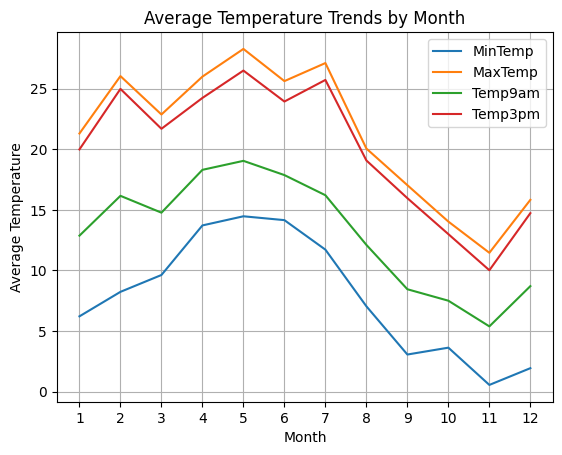

In [ ]:
import matplotlib.pyplot as plt

plt.plot(monthly_weather.index, monthly_weather['MinTemp'], label='MinTemp')
plt.plot(monthly_weather.index, monthly_weather['MaxTemp'], label='MaxTemp')
plt.plot(monthly_weather.index, monthly_weather['Temp9am'], label='Temp9am')
plt.plot(monthly_weather.index, monthly_weather['Temp3pm'], label='Temp3pm')
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.title('Average Temperature Trends by Month')
plt.xticks(monthly_weather.index)
plt.legend()
plt.grid(True)
plt.show()


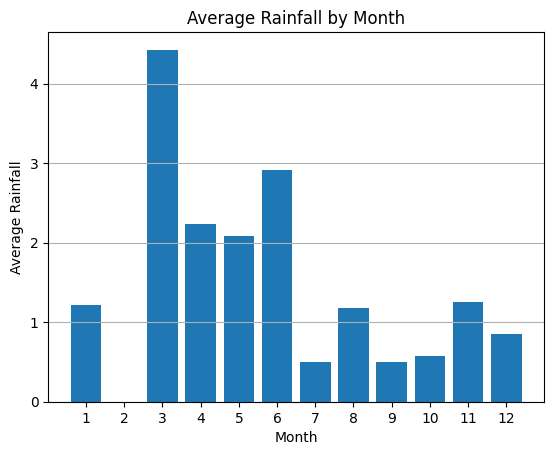

In [ ]:

plt.bar(monthly_weather.index, monthly_weather['Rainfall'])
plt.xlabel('Month')
plt.ylabel('Average Rainfall')
plt.title('Average Rainfall by Month')
plt.xticks(monthly_weather.index)
plt.grid(axis='y')
plt.show()


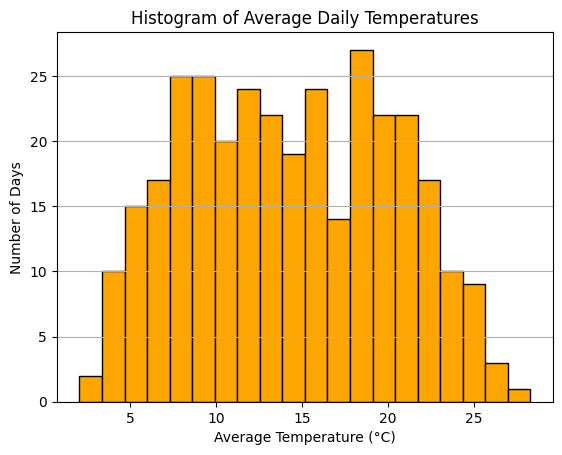

In [ ]:


import matplotlib.pyplot as plt


# Calculate daily average temperature

df['AvgTemp'] = df[['MinTemp', 'MaxTemp']].mean(axis=1)

# Plot histogram of average temperature



plt.hist(df['AvgTemp'].dropna(), bins=20, color='orange', edgecolor='black')

plt.xlabel('Average Temperature (°C)')

plt.ylabel('Number of Days')

plt.title('Histogram of Average Daily Temperatures')

plt.grid(axis='y')

plt.show()


Identify Extreme Weather

In [ ]:
import numpy as np

extreme_temp_threshold = df['MaxTemp'].quantile(0.95)
extreme_rainfall_threshold = df['Rainfall'].quantile(0.95)

extreme_weather_days = df[(df['MaxTemp'] > extreme_temp_threshold) | (df['Rainfall'] > extreme_rainfall_threshold)]
print("Days with extreme temperature or precipitation:")
display(extreme_weather_days)


Days with extreme temperature or precipitation:


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow,Date,Month,Month_in_year,Year,AvgTemp
3,13.3,15.5,39.8,7.2,9.1,NW,54.0,WNW,W,30.0,...,13.5,14.1,Yes,2.8,Yes,2015-03-20,3,3,2015,14.40
9,8.4,22.8,16.2,5.4,7.7,E,31.0,S,ESE,7.0,...,13.3,21.7,Yes,0.0,No,2015-03-26,3,3,2015,15.60
22,12.8,18.5,25.8,2.8,0.6,ESE,28.0,S,SE,13.0,...,14.0,16.8,Yes,0.4,No,2015-04-08,4,4,2015,15.65
30,15.1,20.4,22.6,2.4,0.2,SSE,41.0,E,S,6.0,...,17.0,16.3,Yes,4.2,Yes,2015-04-16,4,4,2015,17.75
51,19.9,22.0,11.0,4.4,5.9,NNW,76.0,N,WNW,41.0,...,20.6,19.6,Yes,17.4,Yes,2015-05-07,5,5,2015,20.95
52,9.2,20.4,17.4,7.8,10.2,ENE,39.0,N,N,9.0,...,14.9,18.8,Yes,0.0,No,2015-05-08,5,5,2015,14.80
57,15.1,28.3,14.4,8.8,13.2,NNW,28.0,NNW,NW,6.0,...,18.3,27.4,Yes,0.0,No,2015-05-13,5,5,2015,21.70
59,15.4,35.0,0.0,9.6,13.0,E,39.0,SSW,ESE,6.0,...,23.4,34.3,No,0.0,No,2015-05-15,5,5,2015,25.20
60,13.8,33.5,0.0,11.4,13.6,NE,31.0,SSE,NE,7.0,...,21.9,32.2,No,0.0,No,2015-05-16,5,5,2015,23.65
61,13.6,34.2,0.0,8.8,12.8,NNE,35.0,ESE,W,2.0,...,21.9,31.8,No,0.0,No,2015-05-17,5,5,2015,23.90


# ============================================================
# 🌦️ WEATHER DATA ANALYSIS PIPELINE
# ============================================================

# 1️⃣ Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# 2️⃣ Upload CSV file
uploaded = files.upload()

for fn in uploaded.keys():
    print('User uploaded file "{name}" with length {length} bytes'.format(
        name=fn, length=len(uploaded[fn])
    ))
    df = pd.read_csv(fn)

# ============================================================
# 3️⃣ Display initial data and add Date column
# ============================================================

# Add a date column starting from 17 March 2015
start_date = '2015-03-17'
df['Date'] = pd.date_range(start=start_date, periods=len(df), freq='D')

# Display first few rows and data types
display(df.head())
print("\nData types:")
print(df.dtypes)

# ============================================================
# 4️⃣ Handle Missing Values using Pandas methods
# ============================================================

# Handle numeric missing values
df.fillna(df.median(numeric_only=True), inplace=True)

# Handle categorical missing values
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Verify missing values handled
print("✅ Missing values after cleaning:")
print(df.isnull().sum())

# ============================================================
# 5️⃣ Convert Date Columns to Datetime Format
# ============================================================

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print("✅ Date column converted to datetime:")
print(df['Date'].dtypes)
print(df[['Date']].head())

# ============================================================
# 6️⃣ Calculate Mean, Median, and Std for Key Weather Metrics
# ============================================================

weather_cols = [
    'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm',
    'Humidity9am', 'Humidity3pm', 'Rainfall', 'RISK_MM'
]
weather_df = df[weather_cols]

weather_stats = weather_df.agg(['mean', 'median', 'std']).round(2)
print("\n📊 Summary Statistics (Mean, Median, Std):")
display(weather_stats)

# ============================================================
# 7️⃣ Group Data by Month
# ============================================================

df['Month'] = df['Date'].dt.month
weather_cols_for_grouping = [
    'MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm',
    'Humidity9am', 'Humidity3pm', 'Rainfall', 'RISK_MM'
]
monthly_weather = df.groupby('Month')[weather_cols_for_grouping].mean().round(2)
print("\n📆 Monthly Average Weather Metrics:")
display(monthly_weather)

# ============================================================
# 8️⃣ Analyze and Compare Average Values of Key Metrics
# ============================================================

key_metrics = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
    'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm'
]

# Keep only columns that exist
key_metrics = [col for col in key_metrics if col in df.columns]

avg_values = df[key_metrics].mean().round(2)
print("\n📈 Average Values of Key Metrics:\n")
print(avg_values)

# 🌤️ Morning vs Afternoon Comparison
morning_cols = ['Temp9am', 'Humidity9am', 'Pressure9am', 'Cloud9am']
afternoon_cols = ['Temp3pm', 'Humidity3pm', 'Pressure3pm', 'Cloud3pm']

if all(col in df.columns for col in morning_cols + afternoon_cols):
    comparison = pd.DataFrame({
        'Morning (9am)': [
            df['Temp9am'].mean(),
            df['Humidity9am'].mean(),
            df['Pressure9am'].mean(),
            df['Cloud9am'].mean()
        ],
        'Afternoon (3pm)': [
            df['Temp3pm'].mean(),
            df['Humidity3pm'].mean(),
            df['Pressure3pm'].mean(),
            df['Cloud3pm'].mean()
        ]
    }, index=['Temperature', 'Humidity', 'Pressure', 'Cloud Cover']).round(2)

    print("\n🌤️ Morning vs Afternoon Comparison:")
    display(comparison)

# ============================================================
# 9️⃣ Line Plot: Monthly Average Temperature Trends
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(monthly_weather.index, monthly_weather['MinTemp'], label='MinTemp')
plt.plot(monthly_weather.index, monthly_weather['MaxTemp'], label='MaxTemp')
plt.plot(monthly_weather.index, monthly_weather['Temp9am'], label='Temp9am')
plt.plot(monthly_weather.index, monthly_weather['Temp3pm'], label='Temp3pm')
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.title('Average Temperature Trends by Month')
plt.xticks(monthly_weather.index)
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 🔟 Bar Plot: Monthly Average Rainfall
# ============================================================

plt.figure(figsize=(12, 6))
plt.bar(monthly_weather.index, monthly_weather['Rainfall'])
plt.xlabel('Month')
plt.ylabel('Average Rainfall')
plt.title('Average Rainfall by Month')
plt.xticks(monthly_weather.index)
plt.grid(axis='y')
plt.show()

# ============================================================
# 1️⃣1️⃣ Histogram: Temperature Distribution
# ============================================================

temperature_cols = ['MinTemp', 'MaxTemp', 'Temp9am', 'Temp3pm']
df[temperature_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle('Temperature Distribution', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# 1️⃣2️⃣ Use NumPy to Filter Extreme Weather Days
# ============================================================

extreme_temp_threshold = df['MaxTemp'].quantile(0.95)
extreme_rainfall_threshold = df['Rainfall'].quantile(0.95)

extreme_weather_days = df[
    (df['MaxTemp'] > extreme_temp_threshold) |
    (df['Rainfall'] > extreme_rainfall_threshold)
]

print("🌡️🌧️ Days with Extreme Temperature or Precipitation:")
display(extreme_weather_days)

# ============================================================
# ✅ END OF ANALYSIS
# ============================================================

print("\n✅ Weather data analysis complete!")
